In [7]:
from google.colab import files
uploaded = files.upload()

In [37]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
dataset = pd.read_csv('placement_data_large.csv')
X = dataset.iloc[ : , : -1].values
y = dataset.iloc[ : , -1].values

In [25]:
print(dataset.shape)
print(dataset.isnull().sum())
print(dataset.describe())
print(dataset.corr(numeric_only = True))

(300, 11)
CGPA                  0
AptitudeScore         0
CommunicationSkill    0
Internships           0
Projects              0
Certifications        0
MockInterviewScore    0
Backlogs              0
Attendance            0
CodingScore           0
Placed                0
dtype: int64
             CGPA  AptitudeScore  CommunicationSkill  Internships    Projects  \
count  300.000000     300.000000          300.000000   300.000000  300.000000   
mean     7.512267      67.923333            5.456667     1.910000    3.533333   
std      1.508440      17.847293            2.867437     1.442974    2.256664   
min      5.030000      35.000000            1.000000     0.000000    0.000000   
25%      6.115000      54.000000            3.000000     1.000000    2.000000   
50%      7.585000      68.000000            5.000000     2.000000    3.000000   
75%      8.902500      82.000000            8.000000     3.000000    5.250000   
max     10.000000      99.000000           10.000000     4.000000

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
regressor = LogisticRegression(max_iter = 1000)
regressor.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [21]:
y_pred = regressor.predict(X_test)

In [36]:
y_pred = regressor.predict([[7.94,55,4,1,2,6,45,1,65,60]])
print(y_pred)

[1]


In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy 0.8166666666666667
[[15  5]
 [ 6 34]]


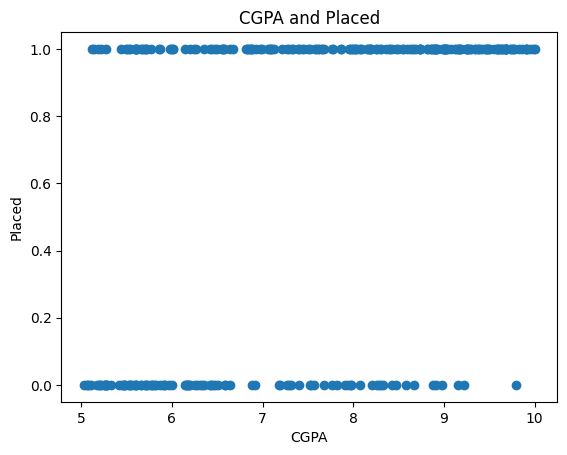

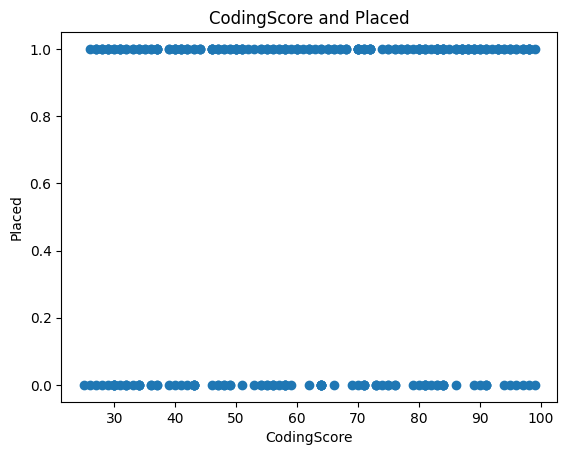

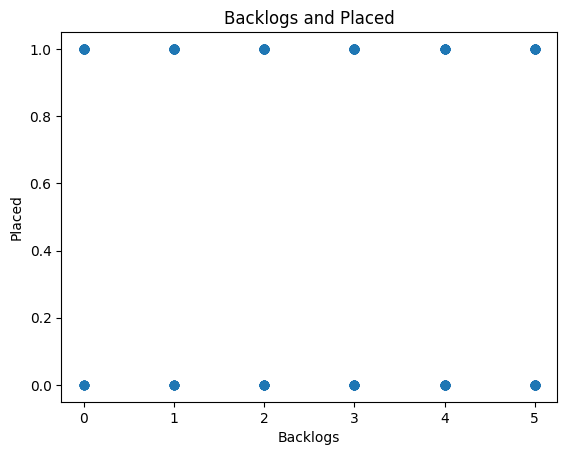

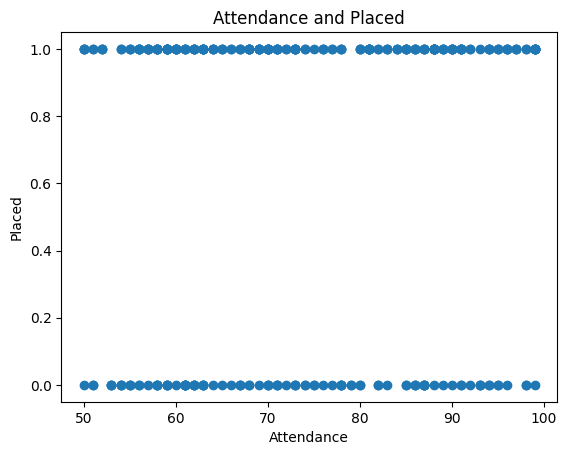

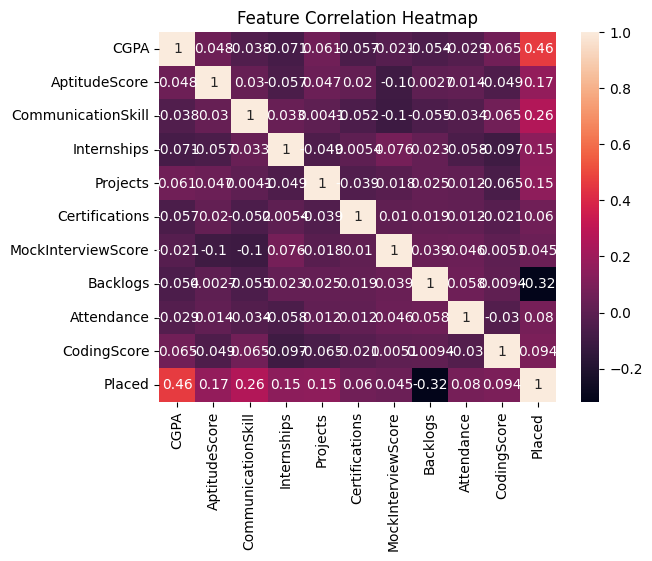

In [41]:
plt.scatter(dataset["CGPA"],dataset["Placed"])
plt.title("CGPA and Placed")
plt.xlabel("CGPA")
plt.ylabel("Placed")
plt.show()

plt.scatter(dataset["CodingScore"],dataset["Placed"])
plt.title("CodingScore and Placed")
plt.xlabel("CodingScore")
plt.ylabel("Placed")
plt.show()

plt.scatter(dataset["Backlogs"],dataset["Placed"])
plt.title("Backlogs and Placed")
plt.xlabel("Backlogs")
plt.ylabel("Placed")
plt.show()

plt.scatter(dataset["Attendance"],dataset["Placed"])
plt.title("Attendance and Placed")
plt.xlabel("Attendance")
plt.ylabel("Placed")
plt.show()

plt.figure()
sn.heatmap(dataset.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()